In [3]:
# Cell 1 — Imports and setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import os
import warnings

warnings.filterwarnings("ignore")

plt.rcParams["figure.dpi"] = 150
plt.rcParams["figure.figsize"] = (14, 5)
plt.rcParams["font.family"] = "sans-serif"
sns.set_theme(style="darkgrid", palette="muted")

os.makedirs("../outputs", exist_ok=True)

print("All libraries loaded successfully!")
print(f"pandas version: {pd.__version__}")
print(f"numpy version: {np.__version__}")


# Press **Shift+Enter** to run it — you should see:
# ```
# All libraries loaded successfully!
# pandas version: 2.x.x
# numpy version: 1.x.x

All libraries loaded successfully!
pandas version: 2.3.3
numpy version: 2.4.3


In [4]:
# Cell 2 — Load all datasets
races             = pd.read_csv("../data/races.csv")
drivers           = pd.read_csv("../data/drivers.csv")
results           = pd.read_csv("../data/results.csv")
constructors      = pd.read_csv("../data/constructors.csv")
driver_standings  = pd.read_csv("../data/driver_standings.csv")
constructor_standings = pd.read_csv("../data/constructor_standings.csv")
qualifying        = pd.read_csv("../data/qualifying.csv")
circuits          = pd.read_csv("../data/circuits.csv")
pit_stops         = pd.read_csv("../data/pit_stops.csv")
sprint_results    = pd.read_csv("../data/sprint_results.csv")

print("All datasets loaded!")
print(f"Races:                {races.shape}")
print(f"Drivers:              {drivers.shape}")
print(f"Results:              {results.shape}")
print(f"Constructors:         {constructors.shape}")
print(f"Driver standings:     {driver_standings.shape}")
print(f"Constructor standing: {constructor_standings.shape}")
print(f"Qualifying:           {qualifying.shape}")
print(f"Circuits:             {circuits.shape}")
print(f"Pit stops:            {pit_stops.shape}")
print(f"Sprint results:       {sprint_results.shape}")

All datasets loaded!
Races:                (1125, 18)
Drivers:              (861, 9)
Results:              (26759, 18)
Constructors:         (212, 5)
Driver standings:     (34863, 7)
Constructor standing: (13391, 7)
Qualifying:           (10494, 9)
Circuits:             (77, 9)
Pit stops:            (11371, 7)
Sprint results:       (360, 16)


In [5]:
# Cell 3 — Clean data and filter to 2020-2024
# Fix \N missing values (common in this dataset)
results.replace("\\N", np.nan, inplace=True)
qualifying.replace("\\N", np.nan, inplace=True)
driver_standings.replace("\\N", np.nan, inplace=True)
constructor_standings.replace("\\N", np.nan, inplace=True)
sprint_results.replace("\\N", np.nan, inplace=True)

# Convert columns to correct types
results["positionOrder"] = pd.to_numeric(results["positionOrder"], errors="coerce")
results["points"]        = pd.to_numeric(results["points"], errors="coerce")
results["grid"]          = pd.to_numeric(results["grid"], errors="coerce")
results["laps"]          = pd.to_numeric(results["laps"], errors="coerce")

# Filter races to 2020-2024 only
modern_races = races[races["year"].between(2020, 2024)].copy()

# Get raceIds for 2020-2024
modern_raceIds = modern_races["raceId"].tolist()

# Filter all other datasets to match
modern_results   = results[results["raceId"].isin(modern_raceIds)].copy()
modern_quali     = qualifying[qualifying["raceId"].isin(modern_raceIds)].copy()
modern_pitstops  = pit_stops[pit_stops["raceId"].isin(modern_raceIds)].copy()
modern_dstandings = driver_standings[driver_standings["raceId"].isin(modern_raceIds)].copy()

print(f"Modern era races (2020-2024): {len(modern_races)}")
print(f"Modern era results:           {len(modern_results)}")
print(f"Modern era qualifying:        {len(modern_quali)}")
print(f"Modern era pit stops:         {len(modern_pitstops)}")
print(f"\nYears covered: {sorted(modern_races['year'].unique())}")
print(f"Total drivers in this era:    {modern_results['driverId'].nunique()}")
print(f"Total circuits in this era:   {modern_races['circuitId'].nunique()}")

Modern era races (2020-2024): 107
Modern era results:           2139
Modern era qualifying:        2138
Modern era pit stops:         3934

Years covered: [np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]
Total drivers in this era:    36
Total circuits in this era:   30


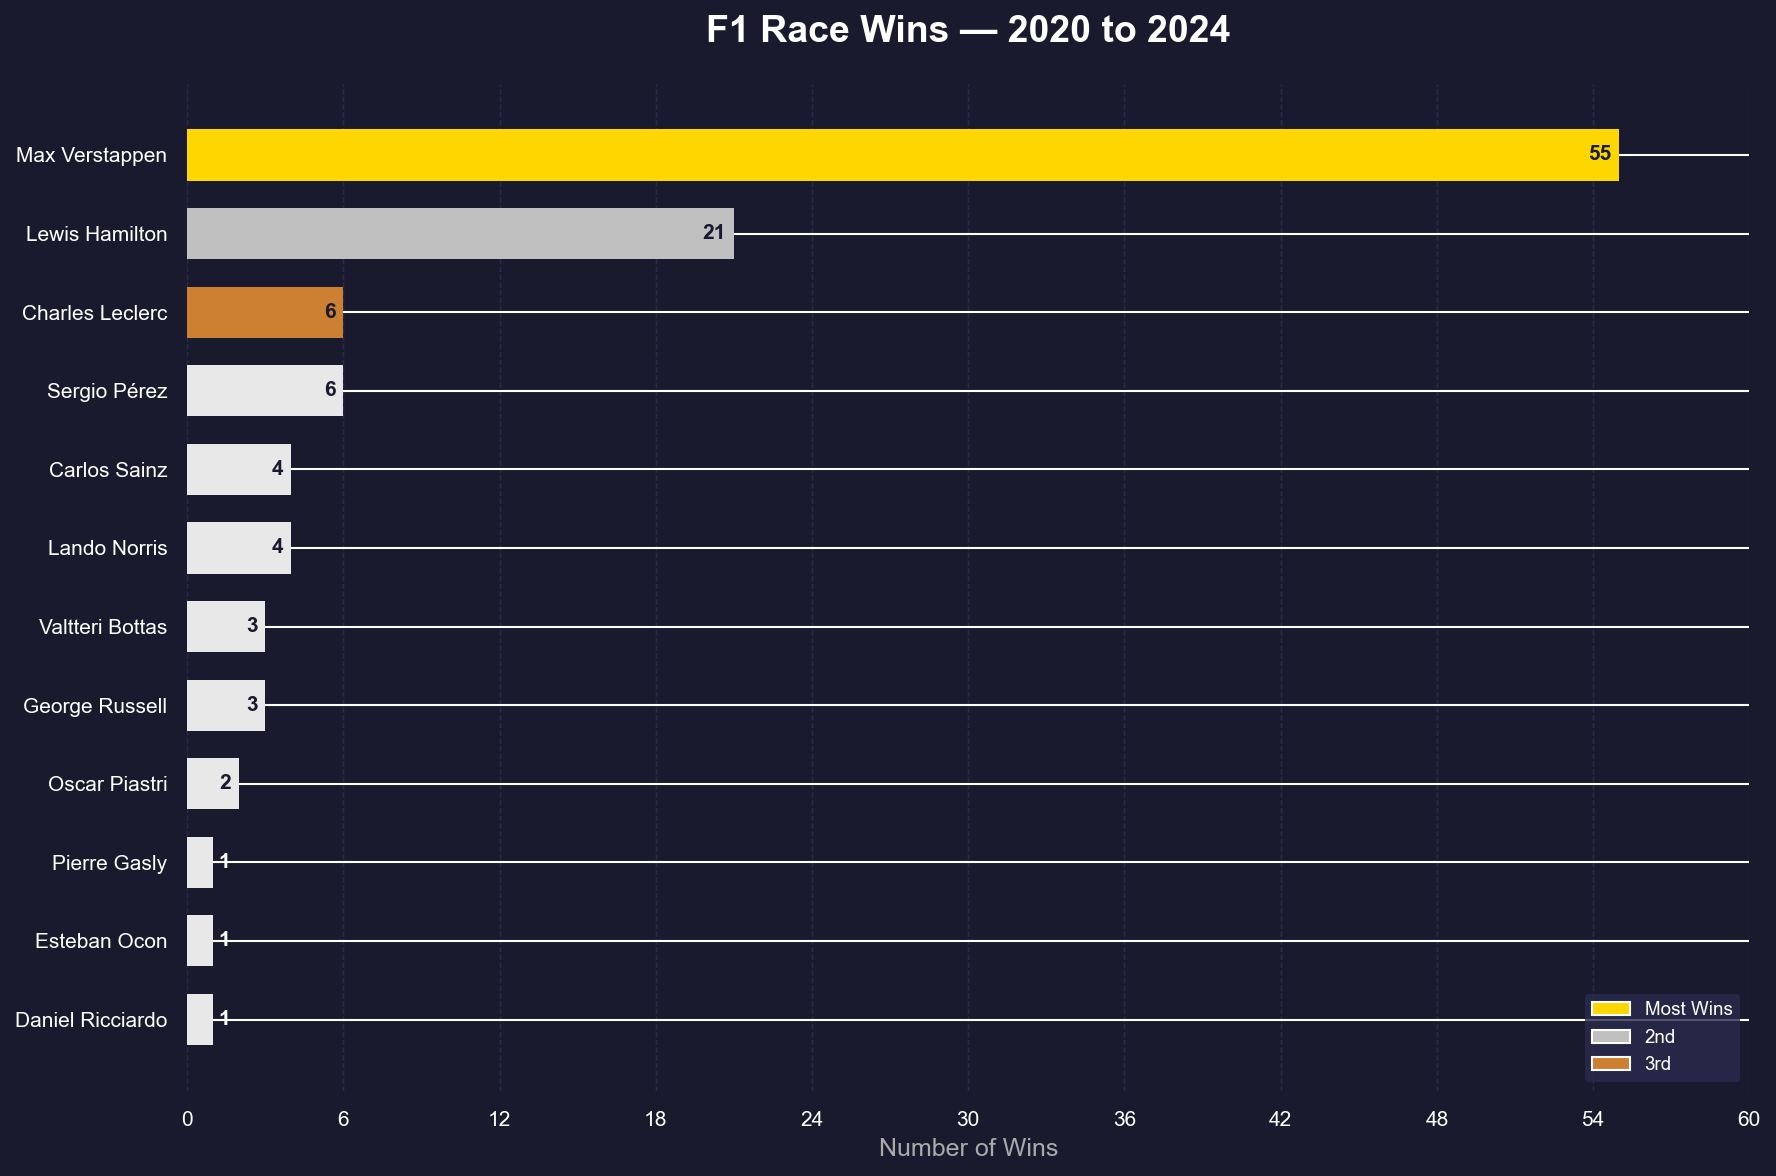

✅ Cell 4 complete — Driver Wins chart saved.


In [6]:
# ============================================================
# CELL 4 — DRIVER WINS 2020-2024
# ============================================================

import matplotlib.ticker as ticker
from matplotlib.patches import Patch

# Filter for race wins (positionOrder == 1) in 2020-2024
# Note: using positionOrder (numeric) not position (has \N values)
wins_df = modern_results[modern_results['positionOrder'] == 1].copy()

# Merge with drivers to get full names
wins_df = wins_df.merge(drivers[['driverId', 'forename', 'surname']], on='driverId', how='left')
wins_df['driver_name'] = wins_df['forename'] + ' ' + wins_df['surname']

# Count wins per driver
win_counts = wins_df['driver_name'].value_counts().reset_index()
win_counts.columns = ['driver_name', 'wins']
win_counts = win_counts.sort_values('wins', ascending=True)  # ascending for horizontal bar

# --- Colour map: highlight top 3 ---
colors = ['#e8e8e8'] * len(win_counts)
top3_positions = list(range(len(win_counts)))[-3:]
palette = ['#CD7F32', '#C0C0C0', '#FFD700']  # bronze, silver, gold
for rank, pos in enumerate(top3_positions):
    colors[pos] = palette[rank]

# --- Plot ---
fig, ax = plt.subplots(figsize=(12, 8))
fig.patch.set_facecolor('#1a1a2e')
ax.set_facecolor('#1a1a2e')

bars = ax.barh(win_counts['driver_name'], win_counts['wins'],
               color=colors, edgecolor='none', height=0.65)

# Add value labels inside bars
for bar, val in zip(bars, win_counts['wins']):
    label_x = bar.get_width() - 0.3 if bar.get_width() > 1 else bar.get_width() + 0.2
    ha = 'right' if bar.get_width() > 1 else 'left'
    ax.text(label_x, bar.get_y() + bar.get_height() / 2,
            str(int(val)), va='center', ha=ha, fontsize=10,
            fontweight='bold', color='#1a1a2e' if bar.get_width() > 1 else 'white')

# Styling
ax.set_title('F1 Race Wins — 2020 to 2024', fontsize=18, fontweight='bold',
             color='white', pad=20)
ax.set_xlabel('Number of Wins', fontsize=12, color='#aaaaaa')
ax.tick_params(colors='white', labelsize=10)
ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
ax.spines[['top', 'right', 'left', 'bottom']].set_visible(False)
ax.grid(axis='x', color='#333355', linestyle='--', linewidth=0.7, alpha=0.7)
ax.set_xlim(0, win_counts['wins'].max() + 5)

# Legend
legend_elements = [Patch(facecolor='#FFD700', label='Most Wins'),
                   Patch(facecolor='#C0C0C0', label='2nd'),
                   Patch(facecolor='#CD7F32', label='3rd')]
ax.legend(handles=legend_elements, loc='lower right',
          facecolor='#2a2a4e', edgecolor='none', labelcolor='white', fontsize=9)

plt.tight_layout()
plt.savefig('driver_wins_2020_2024.png', dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()
print("✅ Cell 4 complete — Driver Wins chart saved.")

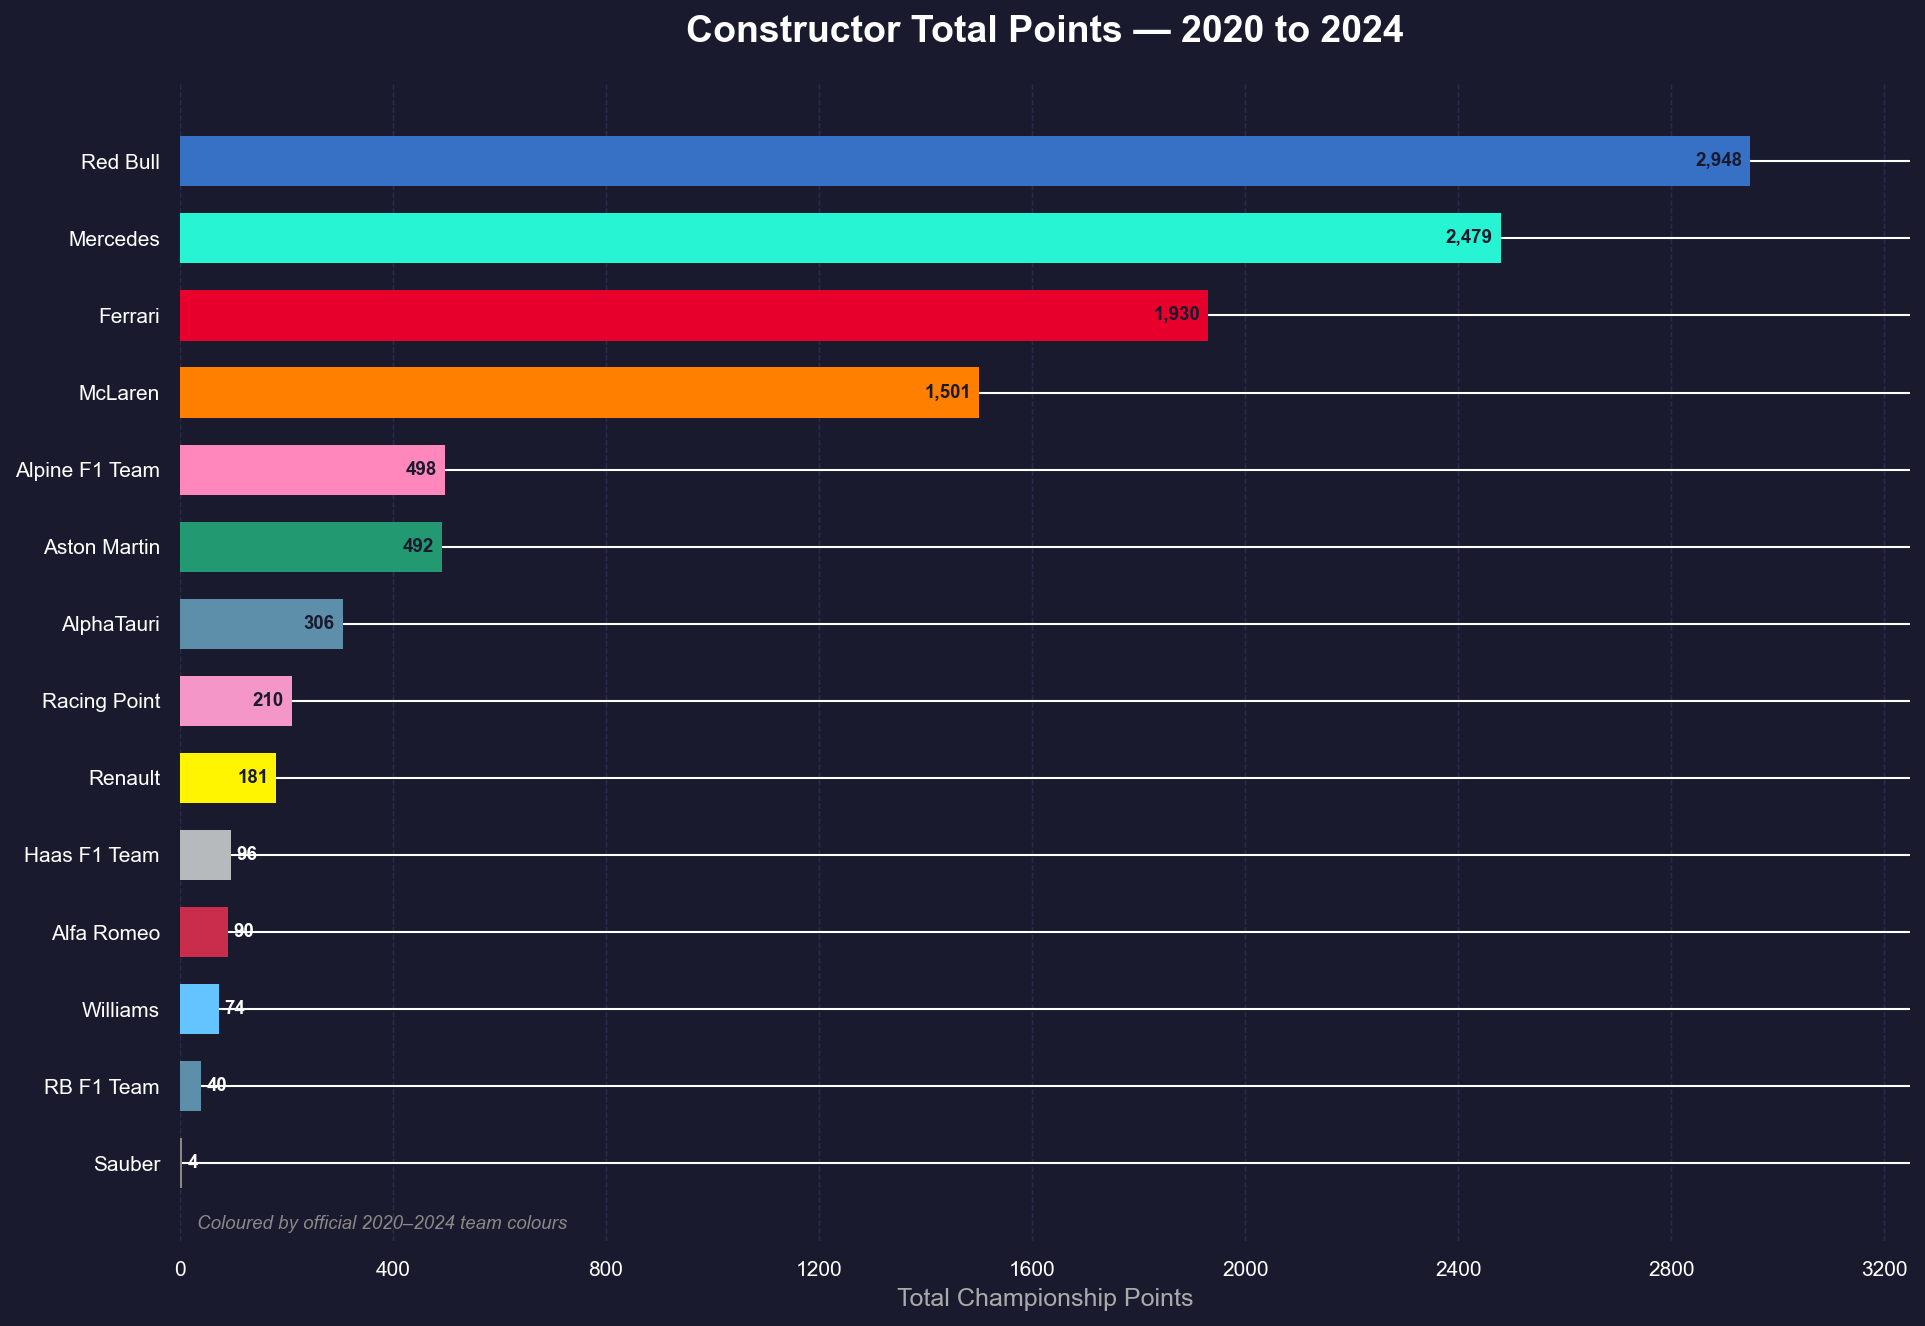

✅ Cell 5 complete — Constructor Points chart saved.


In [7]:
# ============================================================
# CELL 5 — CONSTRUCTOR CHAMPIONSHIP POINTS 2020-2024
# ============================================================

# Merge modern_results with constructors to get team names
constructor_pts = modern_results.merge(
    constructors[['constructorId', 'name']], on='constructorId', how='left'
)

# Sum total points per constructor across 2020-2024
constructor_totals = constructor_pts.groupby('name')['points'].sum().reset_index()
constructor_totals.columns = ['constructor', 'total_points']
constructor_totals = constructor_totals.sort_values('total_points', ascending=True)

# --- F1 team colours (2020-2024 grid) ---
team_colors = {
    'Red Bull':          '#3671C6',
    'Mercedes':          '#27F4D2',
    'Ferrari':           '#E8002D',
    'McLaren':           '#FF8000',
    'Aston Martin':      '#229971',
    'Alpine F1 Team':    '#FF87BC',
    'Williams':          '#64C4FF',
    'AlphaTauri':        '#5E8FAA',
    'RB F1 Team':        '#5E8FAA',
    'Alfa Romeo':        '#C92D4B',
    'Haas F1 Team':      '#B6BABD',
    'Racing Point':      '#F596C8',
    'Renault':           '#FFF500',
    'Toro Rosso':        '#5E8FAA',
    'Alfa Romeo Racing': '#C92D4B',
}

# Assign colours — fallback to grey if team not in dict
bar_colors = [
    team_colors.get(team, '#888888')
    for team in constructor_totals['constructor']
]

# --- Plot ---
fig, ax = plt.subplots(figsize=(13, 9))
fig.patch.set_facecolor('#1a1a2e')
ax.set_facecolor('#1a1a2e')

bars = ax.barh(
    constructor_totals['constructor'],
    constructor_totals['total_points'],
    color=bar_colors, edgecolor='none', height=0.65
)

# Value labels
for bar, val in zip(bars, constructor_totals['total_points']):
    label_x = bar.get_width() - 15 if bar.get_width() > 100 else bar.get_width() + 10
    ha       = 'right' if bar.get_width() > 100 else 'left'
    ax.text(label_x, bar.get_y() + bar.get_height() / 2,
            f'{int(val):,}', va='center', ha=ha, fontsize=9,
            fontweight='bold',
            color='#1a1a2e' if bar.get_width() > 100 else 'white')

# Styling
ax.set_title('Constructor Total Points — 2020 to 2024', fontsize=18,
             fontweight='bold', color='white', pad=20)
ax.set_xlabel('Total Championship Points', fontsize=12, color='#aaaaaa')
ax.tick_params(colors='white', labelsize=10)
ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
ax.spines[['top', 'right', 'left', 'bottom']].set_visible(False)
ax.grid(axis='x', color='#333355', linestyle='--', linewidth=0.7, alpha=0.7)
ax.set_xlim(0, constructor_totals['total_points'].max() + 300)

# Subtitle annotation
ax.annotate('Coloured by official 2020–2024 team colours',
            xy=(0.01, 0.01), xycoords='axes fraction',
            fontsize=9, color='#888888', style='italic')

plt.tight_layout()
plt.savefig('constructor_points_2020_2024.png', dpi=150,
            bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
print("✅ Cell 5 complete — Constructor Points chart saved.")

Top 5 drivers (2023-2024): ['Max Verstappen', 'Lando Norris', 'Charles Leclerc', 'Carlos Sainz', 'Lewis Hamilton']


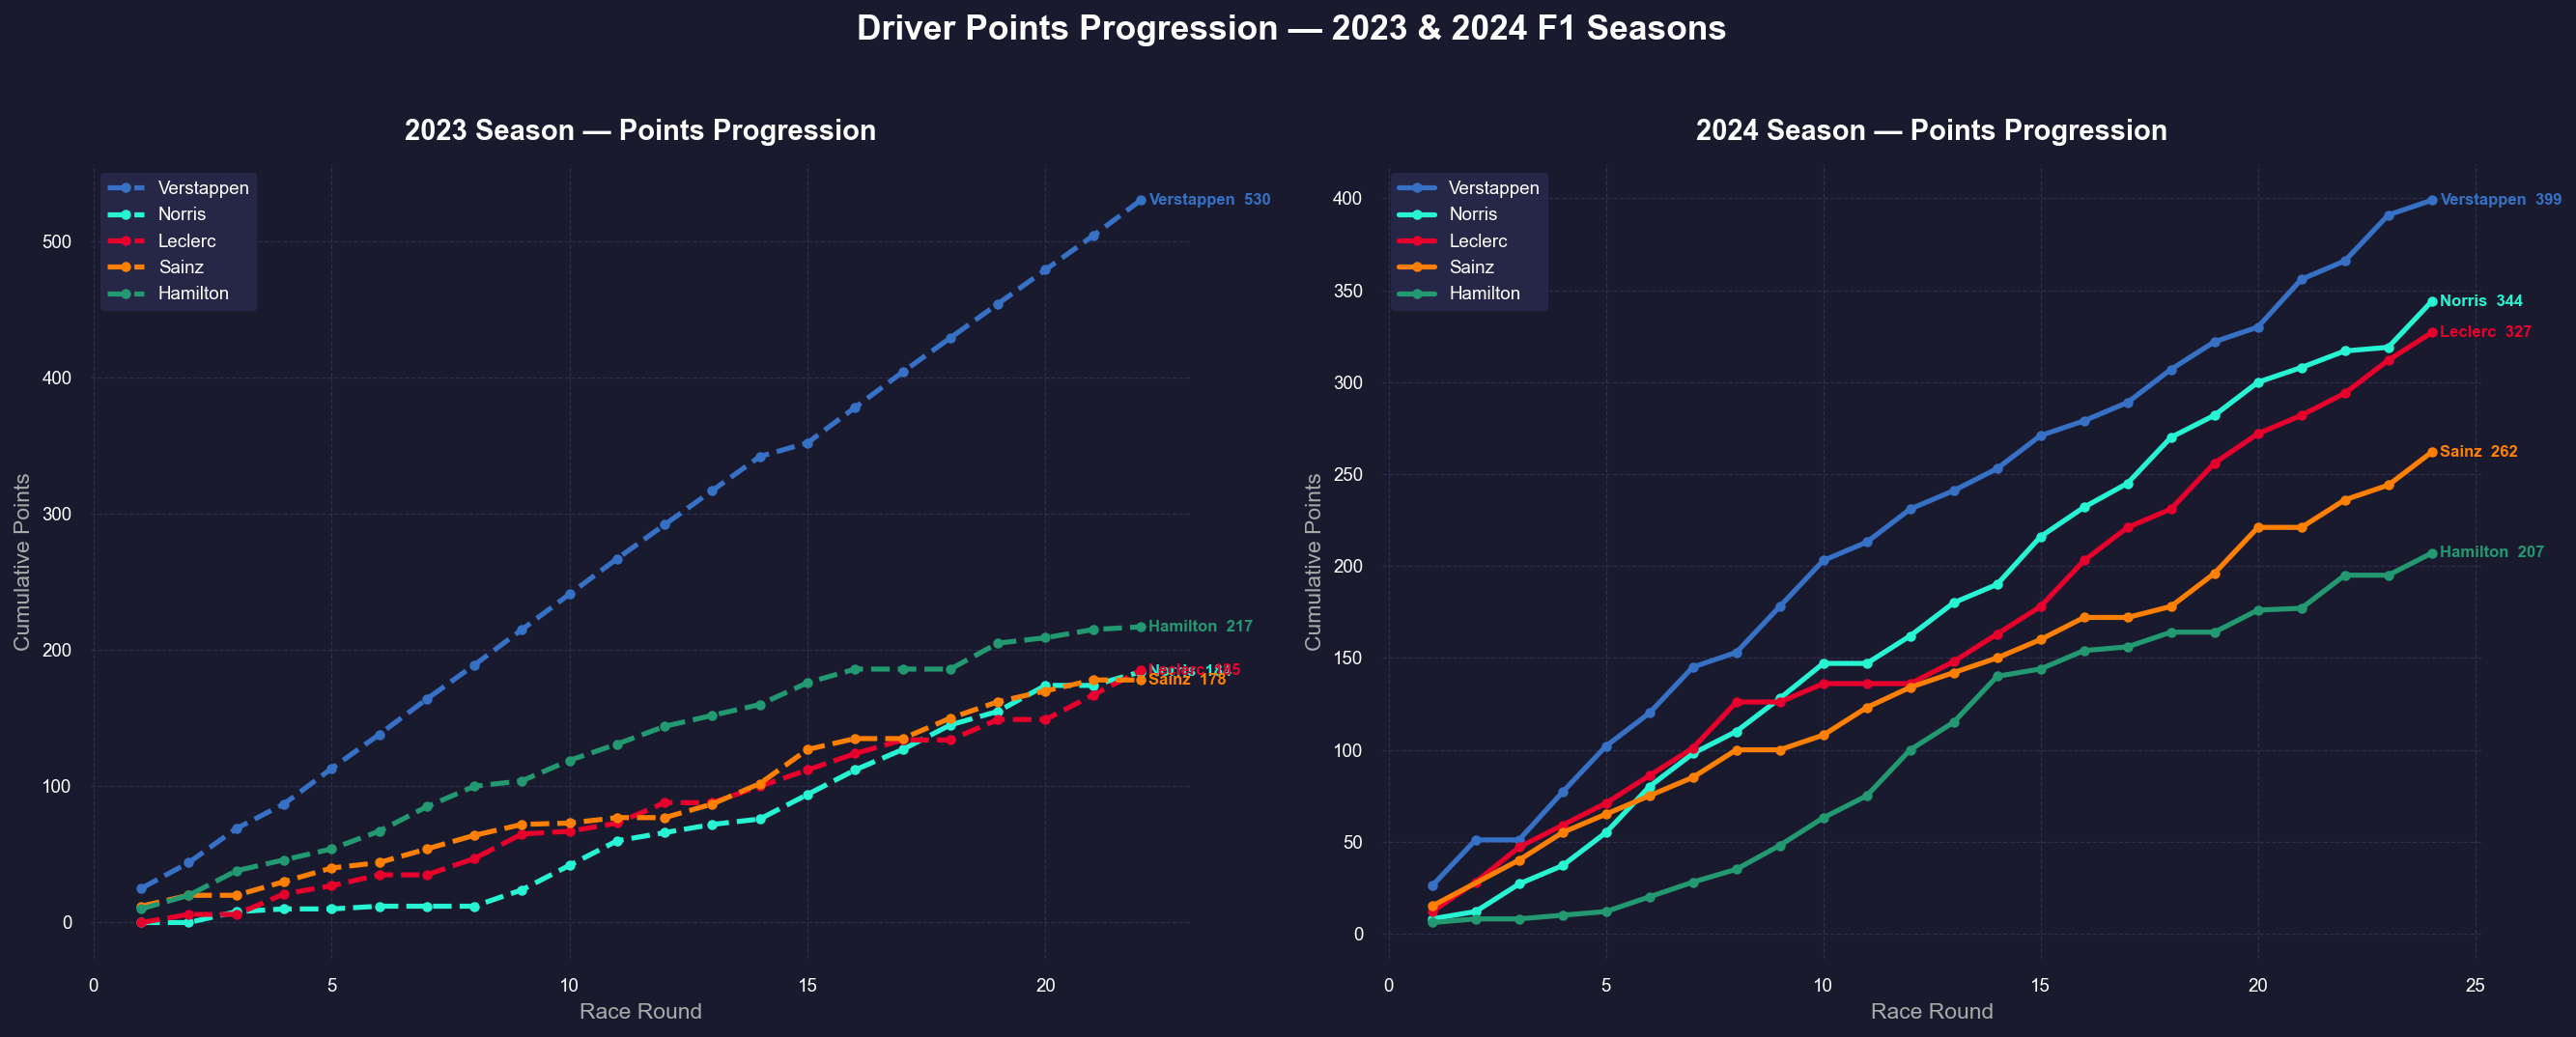

✅ Cell 6 complete — Points Progression chart saved.


In [8]:
# ============================================================
# CELL 6 — POINTS PROGRESSION 2023 & 2024 (TOP 5 DRIVERS)
# ============================================================

# Filter to 2023 and 2024 only
races_2324 = modern_races[modern_races['year'].isin([2023, 2024])].copy()
results_2324 = modern_results[modern_results['raceId'].isin(races_2324['raceId'])].copy()

# Merge results with race info to get round number + year
results_2324 = results_2324.merge(
    races_2324[['raceId', 'year', 'round', 'name']], on='raceId', how='left'
)

# Merge with drivers for names
results_2324 = results_2324.merge(
    drivers[['driverId', 'forename', 'surname']], on='driverId', how='left'
)
results_2324['driver_name'] = results_2324['forename'] + ' ' + results_2324['surname']

# Sort by year and round so cumsum is correct
results_2324 = results_2324.sort_values(['driver_name', 'year', 'round'])

# Cumulative points per driver per year
results_2324['cumulative_points'] = results_2324.groupby(
    ['driver_name', 'year']
)['points'].cumsum()

# --- Find top 5 drivers by total points across 2023+2024 ---
top5_drivers = (
    results_2324.groupby('driver_name')['points']
    .sum()
    .nlargest(5)
    .index.tolist()
)
print(f"Top 5 drivers (2023-2024): {top5_drivers}")

# Filter to top 5 only
plot_df = results_2324[results_2324['driver_name'].isin(top5_drivers)]

# --- Driver colours ---
driver_colors = {
    top5_drivers[0]: '#3671C6',   # Blue   — likely Verstappen
    top5_drivers[1]: '#27F4D2',   # Teal   — likely Hamilton/Russell
    top5_drivers[2]: '#E8002D',   # Red    — likely Leclerc/Sainz
    top5_drivers[3]: '#FF8000',   # Orange — likely Norris
    top5_drivers[4]: '#229971',   # Green  — likely Alonso
}

# --- Line styles per year ---
line_styles = {2023: '--', 2024: '-'}

# --- Plot ---
fig, axes = plt.subplots(1, 2, figsize=(18, 7), sharey=False)
fig.patch.set_facecolor('#1a1a2e')

for ax, year in zip(axes, [2023, 2024]):
    ax.set_facecolor('#1a1a2e')
    year_df = plot_df[plot_df['year'] == year]

    for driver in top5_drivers:
        d_df = year_df[year_df['driver_name'] == driver].sort_values('round')
        if d_df.empty:
            continue
        ax.plot(
            d_df['round'],
            d_df['cumulative_points'],
            color=driver_colors[driver],
            linewidth=2.5,
            linestyle=line_styles[year],
            marker='o', markersize=4,
            label=driver.split()[-1]   # surname only for clean legend
        )
        # End-of-season label
        last = d_df.iloc[-1]
        ax.annotate(
            f"{driver.split()[-1]}  {int(last['cumulative_points'])}",
            xy=(last['round'], last['cumulative_points']),
            xytext=(4, 0), textcoords='offset points',
            fontsize=8, color=driver_colors[driver],
            va='center', fontweight='bold'
        )

    # Styling per subplot
    ax.set_title(f'{year} Season — Points Progression',
                 fontsize=14, fontweight='bold', color='white', pad=12)
    ax.set_xlabel('Race Round', fontsize=11, color='#aaaaaa')
    ax.set_ylabel('Cumulative Points', fontsize=11, color='#aaaaaa')
    ax.tick_params(colors='white', labelsize=9)
    ax.spines[['top', 'right', 'left', 'bottom']].set_visible(False)
    ax.grid(color='#333355', linestyle='--', linewidth=0.6, alpha=0.8)
    ax.legend(facecolor='#2a2a4e', edgecolor='none',
              labelcolor='white', fontsize=9, loc='upper left')

fig.suptitle('Driver Points Progression — 2023 & 2024 F1 Seasons',
             fontsize=17, fontweight='bold', color='white', y=1.02)

plt.tight_layout()
plt.savefig('points_progression_2023_2024.png', dpi=150,
            bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
print("✅ Cell 6 complete — Points Progression chart saved.")

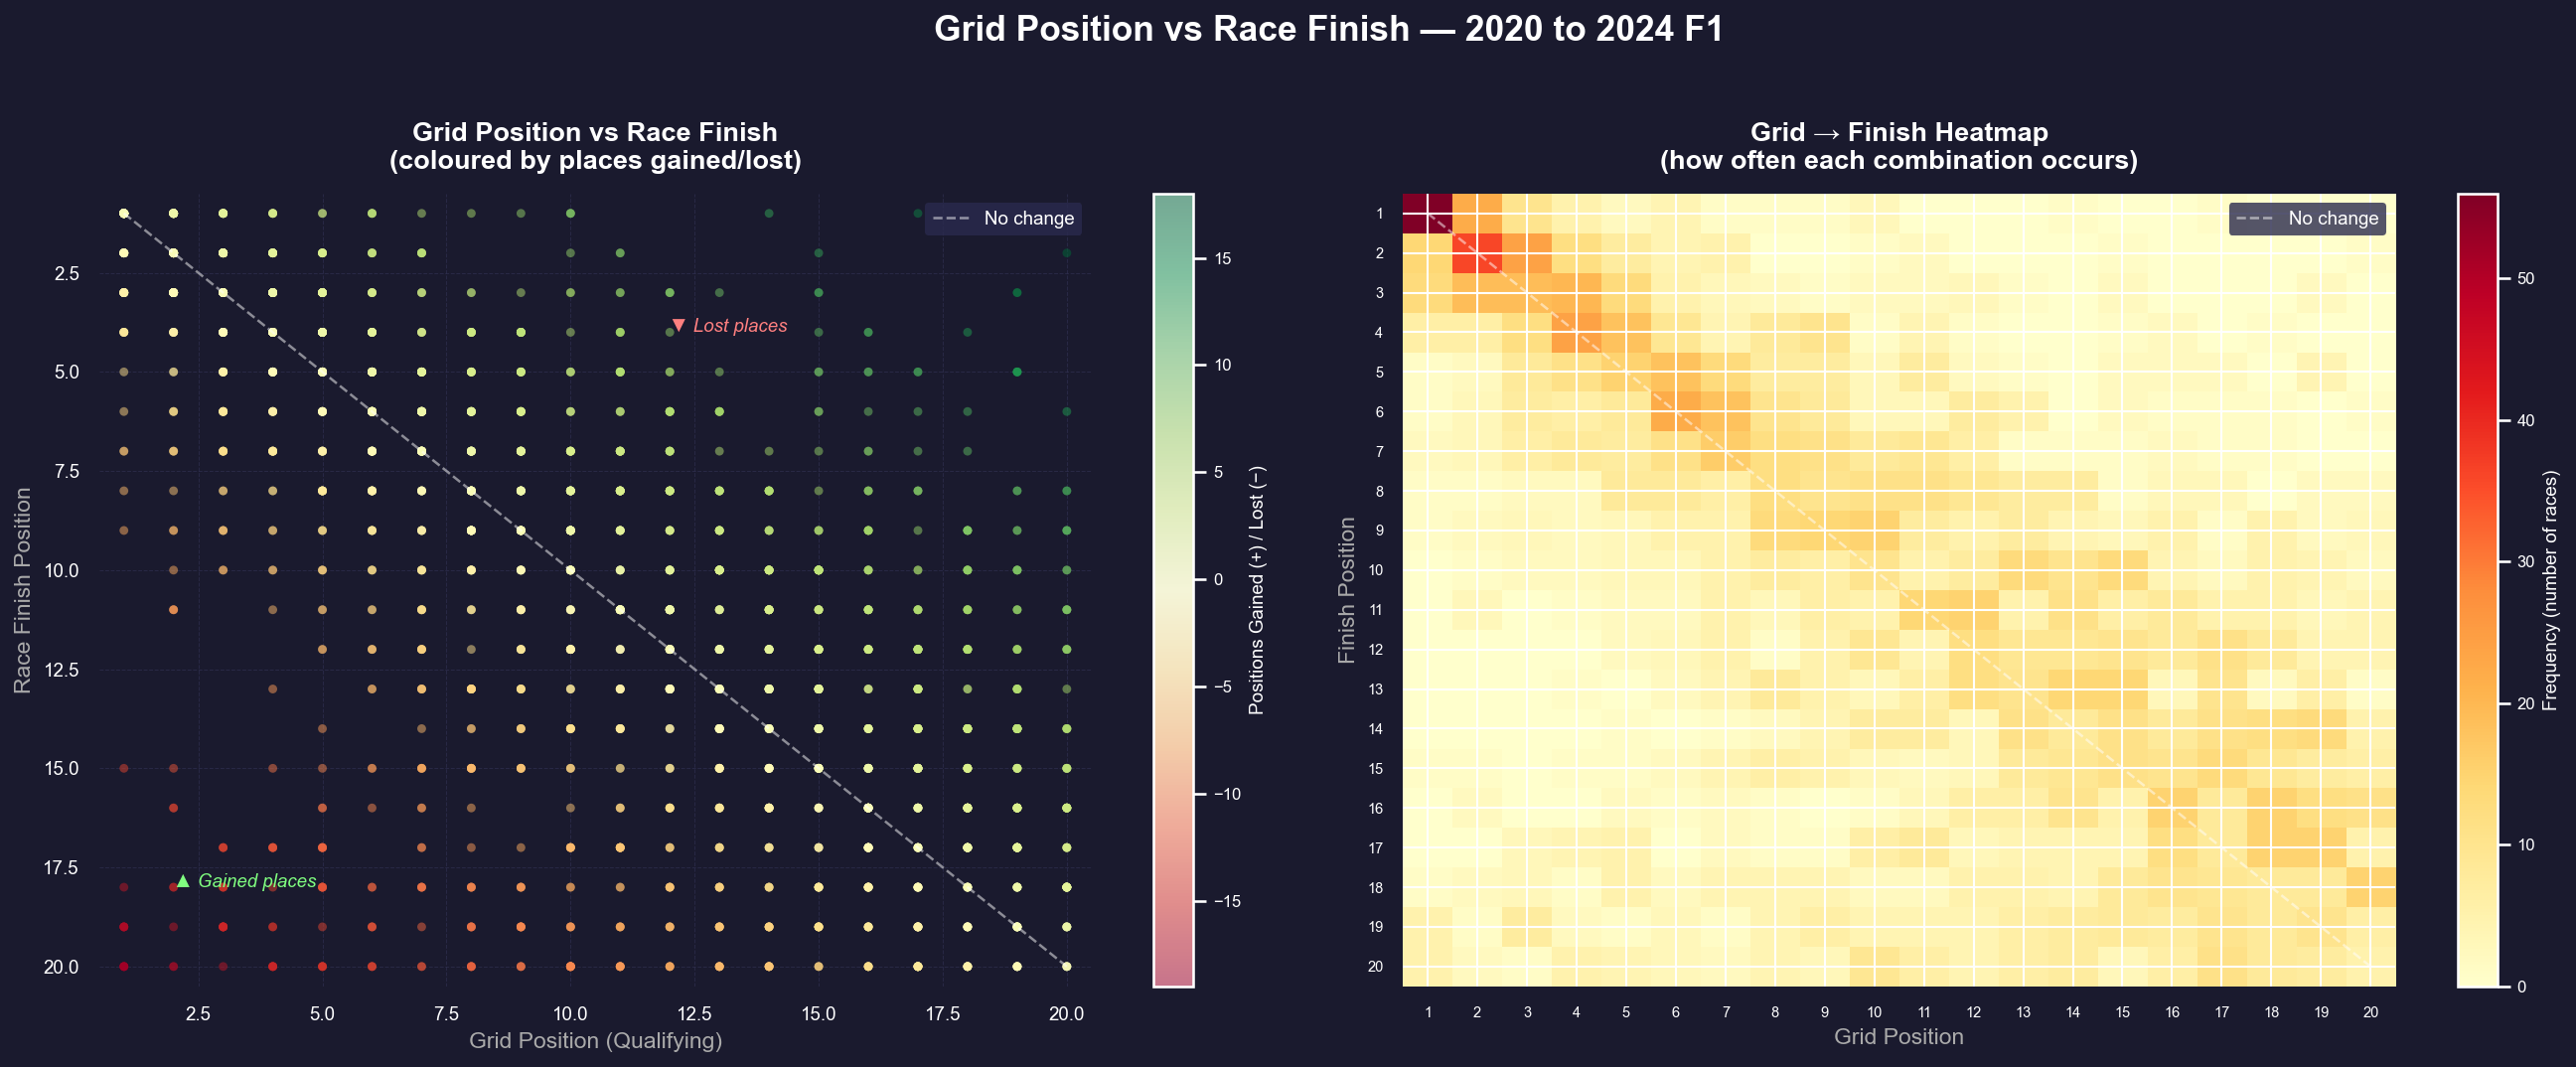

✅ Cell 7 complete — Grid vs Finish chart saved.


In [9]:
# ============================================================
# CELL 7 — GRID POSITION VS RACE FINISH 2020-2024
# ============================================================

# Use modern_results — drop rows where grid or positionOrder is NaN
grid_finish = modern_results[['grid', 'positionOrder', 'driverId']].dropna().copy()

# Remove grid = 0 (pit lane starts) and positions > 20
grid_finish = grid_finish[
    (grid_finish['grid'] > 0) &
    (grid_finish['positionOrder'] <= 20) &
    (grid_finish['grid'] <= 20)
]

# --- Position gained/lost column ---
grid_finish['positions_gained'] = grid_finish['grid'] - grid_finish['positionOrder']

# --- Compute conversion rate: % of time P1 grid → P1 finish etc. ---
# We'll use a heatmap of grid vs finish frequency
pivot = grid_finish.groupby(
    ['grid', 'positionOrder']
).size().reset_index(name='count')

pivot_matrix = pivot.pivot(
    index='positionOrder', columns='grid', values='count'
).fillna(0)

# ============================================================
# PLOT 1 — Scatter: Grid vs Finish coloured by positions gained
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.patch.set_facecolor('#1a1a2e')

# --- Left: Scatter plot ---
ax1 = axes[0]
ax1.set_facecolor('#1a1a2e')

scatter = ax1.scatter(
    grid_finish['grid'],
    grid_finish['positionOrder'],
    c=grid_finish['positions_gained'],
    cmap='RdYlGn',          # Red = lost places, Green = gained places
    alpha=0.5,
    s=18,
    edgecolors='none'
)

# Diagonal line — "no change" reference
ax1.plot([1, 20], [1, 20], color='white', linewidth=1.2,
         linestyle='--', alpha=0.5, label='No change')

# Colorbar
cbar = plt.colorbar(scatter, ax=ax1)
cbar.set_label('Positions Gained (+) / Lost (−)',
               color='white', fontsize=9)
cbar.ax.yaxis.set_tick_params(color='white')
plt.setp(cbar.ax.yaxis.get_ticklabels(), color='white', fontsize=8)

# Annotations
ax1.text(2, 18, '▲ Gained places', color='#80ff80', fontsize=9, style='italic')
ax1.text(12, 4, '▼ Lost places',   color='#ff8080', fontsize=9, style='italic')

ax1.set_title('Grid Position vs Race Finish\n(coloured by places gained/lost)',
              fontsize=13, fontweight='bold', color='white', pad=12)
ax1.set_xlabel('Grid Position (Qualifying)', fontsize=11, color='#aaaaaa')
ax1.set_ylabel('Race Finish Position',       fontsize=11, color='#aaaaaa')
ax1.tick_params(colors='white', labelsize=9)
ax1.spines[['top', 'right', 'left', 'bottom']].set_visible(False)
ax1.grid(color='#333355', linestyle='--', linewidth=0.5, alpha=0.6)
ax1.legend(facecolor='#2a2a4e', edgecolor='none',
           labelcolor='white', fontsize=9)
ax1.set_xlim(0.5, 20.5)
ax1.set_ylim(0.5, 20.5)
ax1.invert_yaxis()

# ============================================================
# PLOT 2 — Heatmap: frequency of each grid→finish combination
# ============================================================
ax2 = axes[1]
ax2.set_facecolor('#1a1a2e')

im = ax2.imshow(
    pivot_matrix.values,
    cmap='YlOrRd',
    aspect='auto',
    interpolation='nearest'
)

cbar2 = plt.colorbar(im, ax=ax2)
cbar2.set_label('Frequency (number of races)',
                color='white', fontsize=9)
cbar2.ax.yaxis.set_tick_params(color='white')
plt.setp(cbar2.ax.yaxis.get_ticklabels(), color='white', fontsize=8)

ax2.set_title('Grid → Finish Heatmap\n(how often each combination occurs)',
              fontsize=13, fontweight='bold', color='white', pad=12)
ax2.set_xlabel('Grid Position', fontsize=11, color='#aaaaaa')
ax2.set_ylabel('Finish Position', fontsize=11, color='#aaaaaa')
ax2.tick_params(colors='white', labelsize=8)
ax2.spines[['top', 'right', 'left', 'bottom']].set_visible(False)

# Fix tick labels to match actual grid positions
ax2.set_xticks(range(len(pivot_matrix.columns)))
ax2.set_xticklabels(pivot_matrix.columns.astype(int), fontsize=7, color='white')
ax2.set_yticks(range(len(pivot_matrix.index)))
ax2.set_yticklabels(pivot_matrix.index.astype(int), fontsize=7, color='white')

# Diagonal overlay on heatmap
diag_len = min(len(pivot_matrix.columns), len(pivot_matrix.index))
ax2.plot(range(diag_len), range(diag_len),
         color='white', linewidth=1.2, linestyle='--',
         alpha=0.5, label='No change')
ax2.legend(facecolor='#2a2a4e', edgecolor='none',
           labelcolor='white', fontsize=9)

# --- Supertitle ---
fig.suptitle('Grid Position vs Race Finish — 2020 to 2024 F1',
             fontsize=17, fontweight='bold', color='white', y=1.02)

plt.tight_layout()
plt.savefig('grid_vs_finish_2020_2024.png', dpi=150,
            bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
print("✅ Cell 7 complete — Grid vs Finish chart saved.")

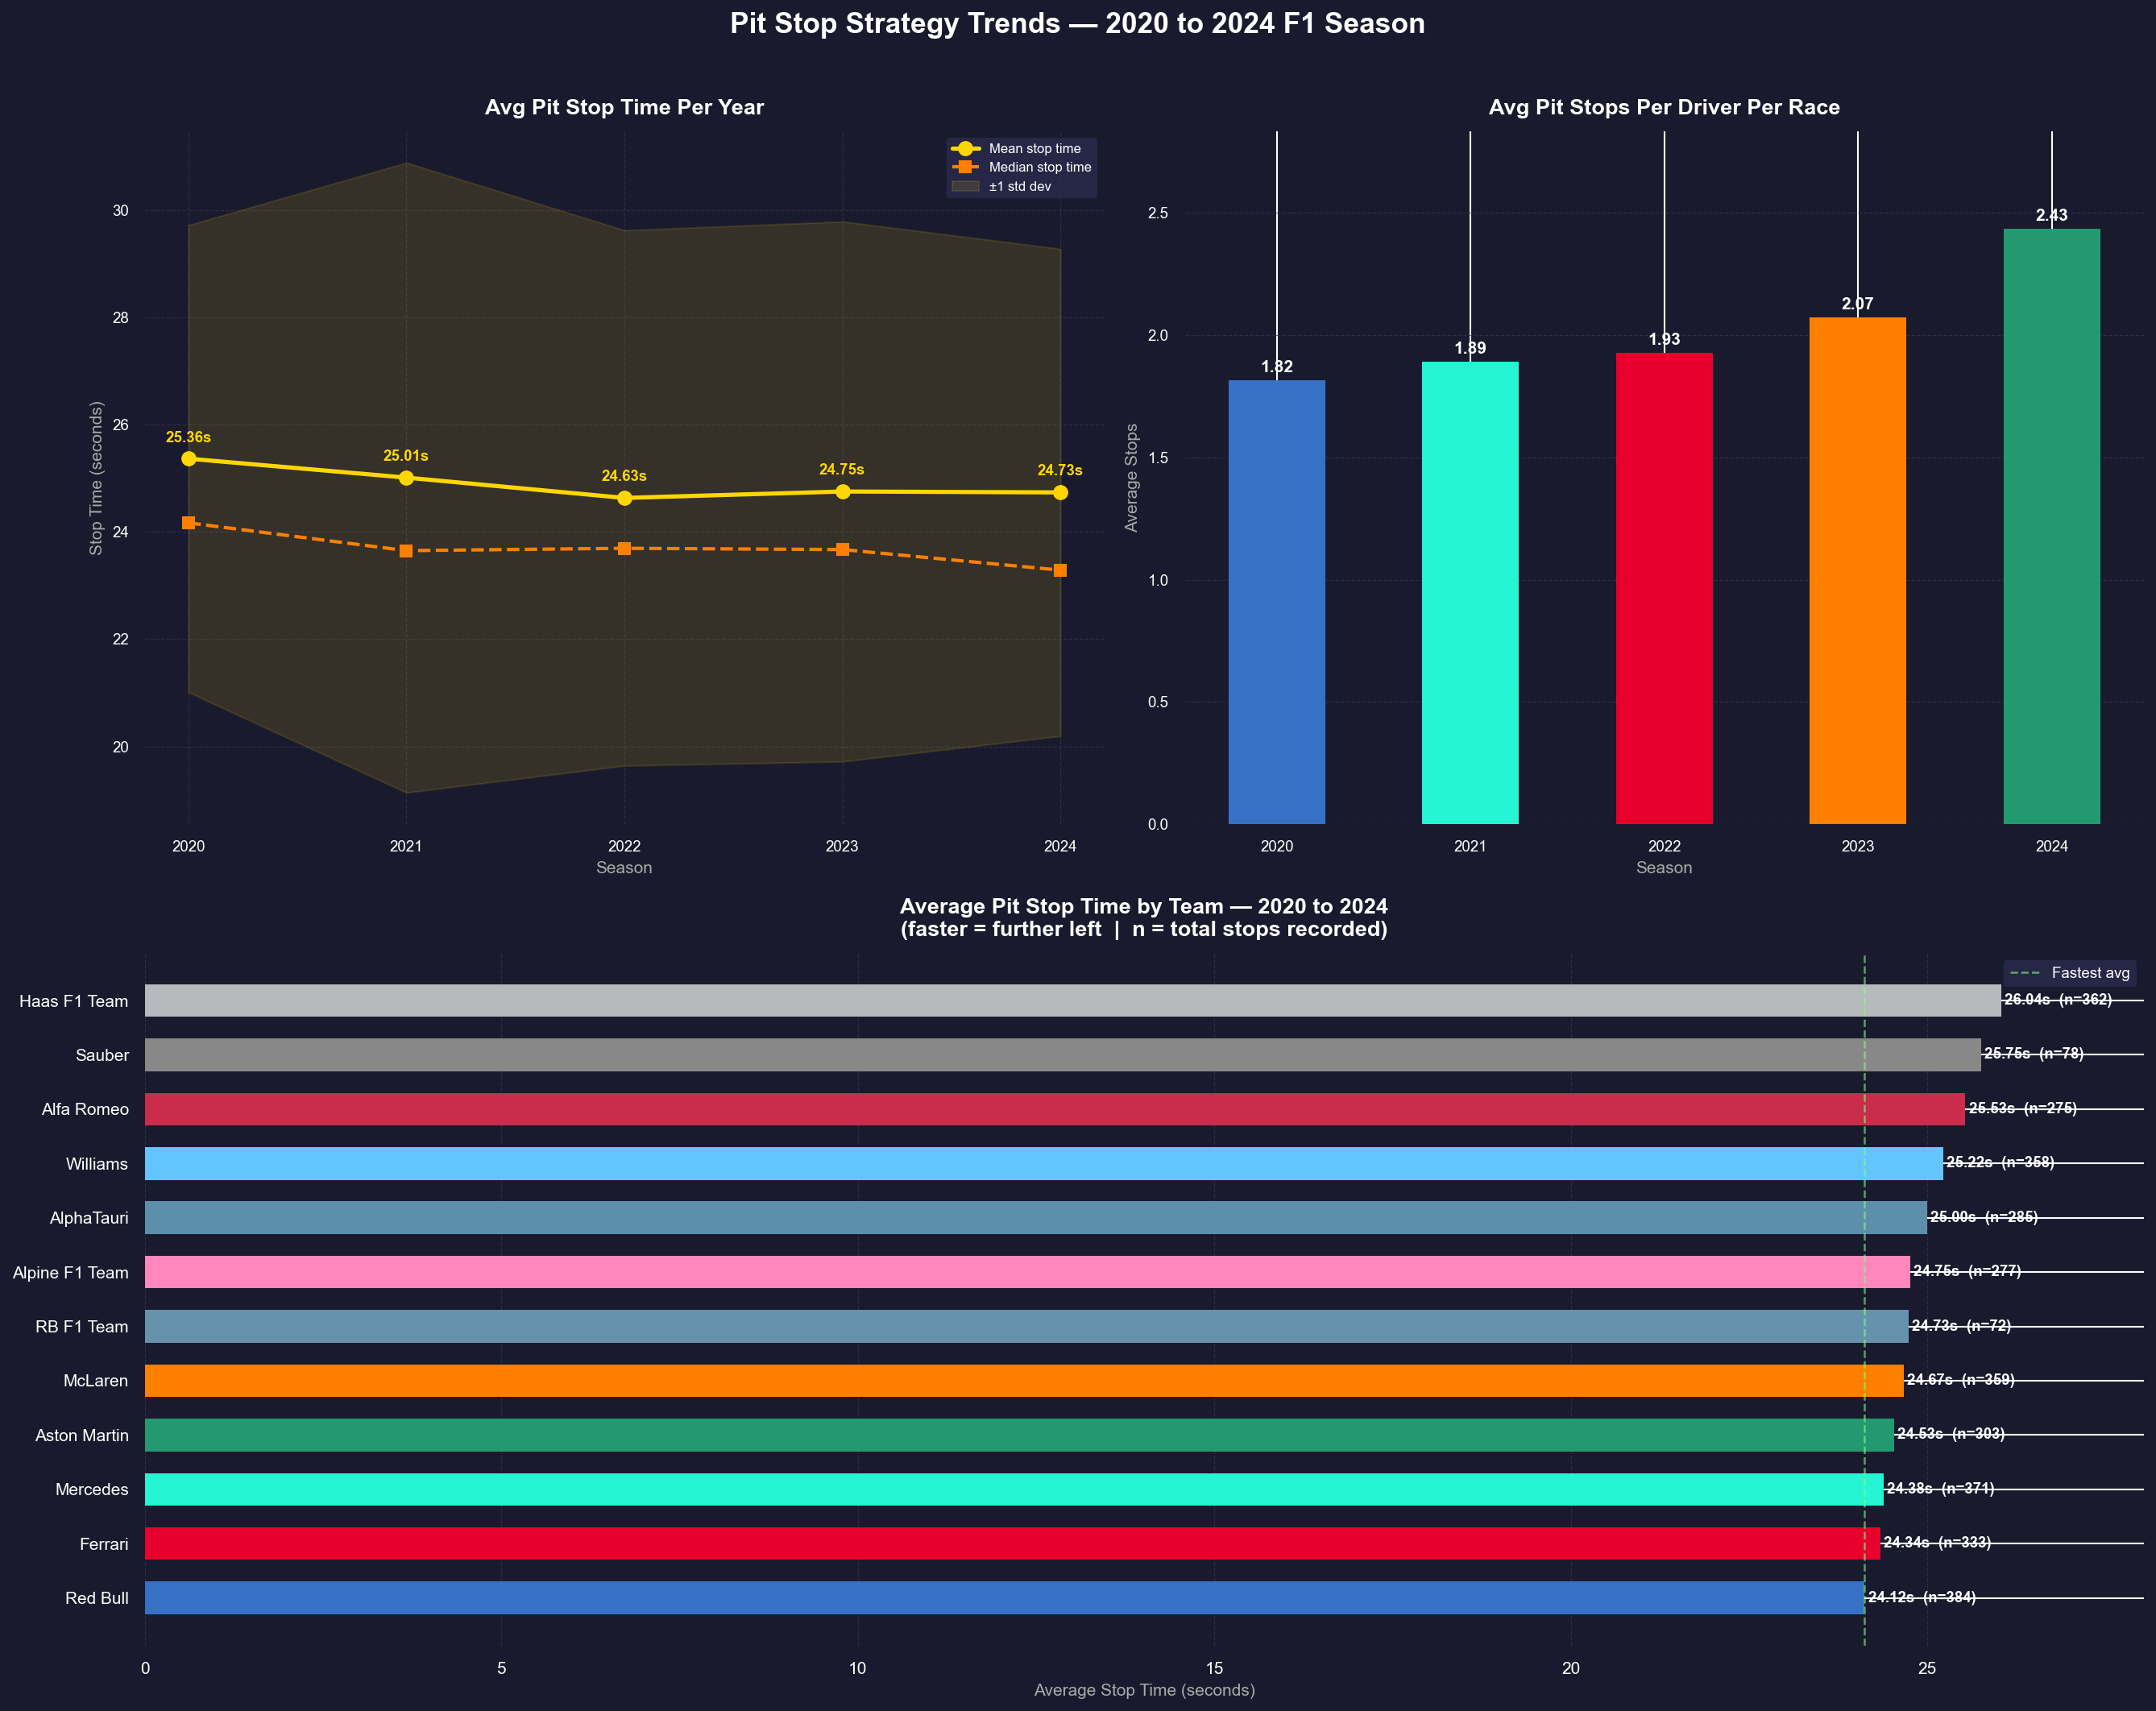

✅ Cell 8 complete — Pit Stop Strategy chart saved.


In [10]:
# ============================================================
# CELL 8 — PIT STOP STRATEGY TRENDS 2020-2024
# ============================================================

import matplotlib.ticker as ticker
from matplotlib.patches import Patch

# --- Clean pit stop data ---
modern_pitstops['milliseconds'] = pd.to_numeric(
    modern_pitstops['milliseconds'], errors='coerce'
)
modern_pitstops['duration'] = pd.to_numeric(
    modern_pitstops['duration'], errors='coerce'
)

# Remove outliers — pit stops under 1.5s or over 60s are errors/safety cars
pitstops_clean = modern_pitstops[
    (modern_pitstops['milliseconds'] >= 1500) &
    (modern_pitstops['milliseconds'] <= 60000)
].copy()

# Merge with races to get year
pitstops_clean = pitstops_clean.merge(
    modern_races[['raceId', 'year', 'round']], on='raceId', how='left'
)

# Merge with results to get constructorId
pitstops_clean = pitstops_clean.merge(
    modern_results[['raceId', 'driverId', 'constructorId']],
    on=['raceId', 'driverId'], how='left'
)

# Merge with constructors to get team name
pitstops_clean = pitstops_clean.merge(
    constructors[['constructorId', 'name']], on='constructorId', how='left'
)
pitstops_clean.rename(columns={'name': 'team'}, inplace=True)

# Convert ms to seconds
pitstops_clean['stop_seconds'] = pitstops_clean['milliseconds'] / 1000

# ============================================================
# DATA AGGREGATIONS
# ============================================================

# 1. Average pit stop time per year (trend over era)
yearly_avg = pitstops_clean.groupby('year')['stop_seconds'].agg(
    ['mean', 'median', 'std']
).reset_index()

# 2. Average number of stops per race per year
stops_per_race = pitstops_clean.groupby(
    ['year', 'raceId', 'driverId']
)['stop'].max().reset_index()
stops_per_race = stops_per_race.groupby('year')['stop'].mean().reset_index()
stops_per_race.columns = ['year', 'avg_stops']

# 3. Fastest average pit stop by team across 2020-2024
team_avg = pitstops_clean.groupby('team')['stop_seconds'].agg(
    ['mean', 'count']
).reset_index()
team_avg.columns = ['team', 'avg_stop_time', 'total_stops']
# Only teams with meaningful sample size
team_avg = team_avg[team_avg['total_stops'] >= 50]
team_avg = team_avg.sort_values('avg_stop_time', ascending=True)

# --- Team colours ---
team_colors = {
    'Red Bull':          '#3671C6',
    'Mercedes':          '#27F4D2',
    'Ferrari':           '#E8002D',
    'McLaren':           '#FF8000',
    'Aston Martin':      '#229971',
    'Alpine F1 Team':    '#FF87BC',
    'Williams':          '#64C4FF',
    'AlphaTauri':        '#5E8FAA',
    'RB F1 Team':        '#6692AD',
    'Alfa Romeo':        '#C92D4B',
    'Haas F1 Team':      '#B6BABD',
    'Racing Point':      '#F596C8',
    'Renault':           '#FFF500',
    'Alfa Romeo Racing': '#C92D4B',
}

bar_colors = [team_colors.get(t, '#888888') for t in team_avg['team']]

# ============================================================
# PLOTS — 3 panel layout
# ============================================================
fig = plt.figure(figsize=(18, 14))
fig.patch.set_facecolor('#1a1a2e')

# --- Layout: 2 top, 1 bottom ---
ax1 = fig.add_subplot(2, 2, 1)   # Avg pit time per year
ax2 = fig.add_subplot(2, 2, 2)   # Avg stops per race per year
ax3 = fig.add_subplot(2, 1, 2)   # Team pit stop performance

# ============================================================
# PLOT 1 — Average Pit Stop Time Per Year
# ============================================================
ax1.set_facecolor('#1a1a2e')

ax1.plot(yearly_avg['year'], yearly_avg['mean'],
         color='#FFD700', linewidth=2.5, marker='o',
         markersize=8, label='Mean stop time', zorder=3)
ax1.plot(yearly_avg['year'], yearly_avg['median'],
         color='#FF8000', linewidth=2, marker='s',
         markersize=7, linestyle='--', label='Median stop time', zorder=3)

# Shaded std band
ax1.fill_between(
    yearly_avg['year'],
    yearly_avg['mean'] - yearly_avg['std'],
    yearly_avg['mean'] + yearly_avg['std'],
    color='#FFD700', alpha=0.12, label='±1 std dev'
)

# Value labels
for _, row in yearly_avg.iterrows():
    ax1.annotate(f"{row['mean']:.2f}s",
                 xy=(row['year'], row['mean']),
                 xytext=(0, 10), textcoords='offset points',
                 ha='center', fontsize=9,
                 color='#FFD700', fontweight='bold')

ax1.set_title('Avg Pit Stop Time Per Year',
              fontsize=13, fontweight='bold', color='white', pad=10)
ax1.set_xlabel('Season', fontsize=10, color='#aaaaaa')
ax1.set_ylabel('Stop Time (seconds)', fontsize=10, color='#aaaaaa')
ax1.tick_params(colors='white', labelsize=9)
ax1.spines[['top', 'right', 'left', 'bottom']].set_visible(False)
ax1.grid(color='#333355', linestyle='--', linewidth=0.6, alpha=0.7)
ax1.legend(facecolor='#2a2a4e', edgecolor='none',
           labelcolor='white', fontsize=8)
ax1.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))

# ============================================================
# PLOT 2 — Average Number of Pit Stops Per Race Per Year
# ============================================================
ax2.set_facecolor('#1a1a2e')

bar_colors_yr = ['#3671C6', '#27F4D2', '#E8002D', '#FF8000', '#229971']
bars = ax2.bar(
    stops_per_race['year'],
    stops_per_race['avg_stops'],
    color=bar_colors_yr[:len(stops_per_race)],
    edgecolor='none', width=0.5
)

for bar, val in zip(bars, stops_per_race['avg_stops']):
    ax2.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 0.02,
             f'{val:.2f}', ha='center', va='bottom',
             fontsize=10, fontweight='bold', color='white')

ax2.set_title('Avg Pit Stops Per Driver Per Race',
              fontsize=13, fontweight='bold', color='white', pad=10)
ax2.set_xlabel('Season', fontsize=10, color='#aaaaaa')
ax2.set_ylabel('Average Stops', fontsize=10, color='#aaaaaa')
ax2.tick_params(colors='white', labelsize=9)
ax2.spines[['top', 'right', 'left', 'bottom']].set_visible(False)
ax2.grid(axis='y', color='#333355', linestyle='--', linewidth=0.6, alpha=0.7)
ax2.set_ylim(0, stops_per_race['avg_stops'].max() + 0.4)
ax2.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))

# ============================================================
# PLOT 3 — Team Pit Stop Performance (fastest → slowest)
# ============================================================
ax3.set_facecolor('#1a1a2e')

bars3 = ax3.barh(
    team_avg['team'],
    team_avg['avg_stop_time'],
    color=bar_colors, edgecolor='none', height=0.6
)

for bar, val, count in zip(bars3, team_avg['avg_stop_time'],
                            team_avg['total_stops']):
    ax3.text(bar.get_width() + 0.05,
             bar.get_y() + bar.get_height() / 2,
             f'{val:.2f}s  (n={int(count)})',
             va='center', ha='left', fontsize=9,
             color='white', fontweight='bold')

# Highlight fastest team
ax3.axvline(x=team_avg['avg_stop_time'].min(),
            color='#80ff80', linewidth=1.2,
            linestyle='--', alpha=0.6, label='Fastest avg')

ax3.set_title('Average Pit Stop Time by Team — 2020 to 2024\n'
              '(faster = further left  |  n = total stops recorded)',
              fontsize=13, fontweight='bold', color='white', pad=10)
ax3.set_xlabel('Average Stop Time (seconds)', fontsize=10, color='#aaaaaa')
ax3.tick_params(colors='white', labelsize=10)
ax3.spines[['top', 'right', 'left', 'bottom']].set_visible(False)
ax3.grid(axis='x', color='#333355', linestyle='--', linewidth=0.6, alpha=0.7)
ax3.set_xlim(0, team_avg['avg_stop_time'].max() + 2)
ax3.legend(facecolor='#2a2a4e', edgecolor='none',
           labelcolor='white', fontsize=9)

# --- Supertitle ---
fig.suptitle('Pit Stop Strategy Trends — 2020 to 2024 F1 Season',
             fontsize=17, fontweight='bold', color='white', y=1.01)

plt.tight_layout()
plt.savefig('pitstop_strategy_2020_2024.png', dpi=150,
            bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
print("✅ Cell 8 complete — Pit Stop Strategy chart saved.")

In [12]:
# ============================================================
# CELL 9 — SUMMARY & KEY INSIGHTS (PART 1 WRAP-UP)
# ============================================================

from datetime import datetime

# ============================================================
# COMPUTE ALL KEY STATS
# ============================================================

# --- Most wins ---
wins_df = modern_results[modern_results['positionOrder'] == 1].copy()
wins_df = wins_df.merge(
    drivers[['driverId', 'forename', 'surname']], on='driverId', how='left'
)
wins_df['driver_name'] = wins_df['forename'] + ' ' + wins_df['surname']
win_counts = wins_df['driver_name'].value_counts()
top_winner = win_counts.index[0]
top_wins   = int(win_counts.iloc[0])

# --- Constructor with most points ---
constructor_pts = modern_results.merge(
    constructors[['constructorId', 'name']], on='constructorId', how='left'
)
constructor_totals = constructor_pts.groupby('name')['points'].sum()
top_constructor     = constructor_totals.idxmax()
top_constructor_pts = int(constructor_totals.max())

# --- Grid vs finish correlation ---
grid_finish = modern_results[['grid', 'positionOrder']].dropna()
grid_finish = grid_finish[
    (grid_finish['grid'] > 0) &
    (grid_finish['positionOrder'] <= 20) &
    (grid_finish['grid'] <= 20)
]
correlation = grid_finish['grid'].corr(grid_finish['positionOrder'])

# --- Pit stop stats ---
modern_pitstops['milliseconds'] = pd.to_numeric(
    modern_pitstops['milliseconds'], errors='coerce'
)
pitstops_clean = modern_pitstops[
    (modern_pitstops['milliseconds'] >= 1500) &
    (modern_pitstops['milliseconds'] <= 60000)
].copy()
pitstops_clean['stop_seconds'] = pitstops_clean['milliseconds'] / 1000
overall_avg_stop = pitstops_clean['stop_seconds'].mean()
overall_med_stop = pitstops_clean['stop_seconds'].median()

# --- P1 grid conversion rate ---
p1_grid = grid_finish[grid_finish['grid'] == 1]
p1_wins = (p1_grid['positionOrder'] == 1).sum()
p1_rate = (p1_wins / len(p1_grid)) * 100

# --- Totals ---
total_races   = len(modern_races)
total_drivers = modern_results['driverId'].nunique()
total_teams   = modern_results['constructorId'].nunique()
total_results = len(modern_results)

# ============================================================
# PRINT SUMMARY TO NOTEBOOK
# ============================================================

summary = f"""
╔══════════════════════════════════════════════════════════════════╗
║        F1 DATA ANALYSIS - PART 1 COMPLETE                       ║
║        Modern Era: 2020-2024  |  {datetime.now().strftime("%d %b %Y")}                    ║
╠══════════════════════════════════════════════════════════════════╣
║                                                                  ║
║  DATASET OVERVIEW                                                ║
║  Total races analysed      : {total_races:<5}                            ║
║  Unique drivers            : {total_drivers:<5}                            ║
║  Unique constructors       : {total_teams:<5}                            ║
║  Total race results        : {total_results:<6}                           ║
║                                                                  ║
║  WINS & DOMINANCE                                                ║
║  Most race wins (driver)   : {top_winner} ({top_wins} wins)
║  Most points (constructor) : {top_constructor} ({top_constructor_pts:,} pts)
║  P1 grid -> P1 finish rate : {p1_rate:.1f}%                             ║
║                                                                  ║
║  GRID vs FINISH                                                  ║
║  Pearson correlation       : {correlation:.4f}                          ║
║  Interpretation            : {'Strong' if correlation > 0.6 else 'Moderate'} positive correlation          ║
║  ML implication            : Grid position is a key feature     ║
║                                                                  ║
║  PIT STOP STRATEGY                                               ║
║  Overall avg stop time     : {overall_avg_stop:.2f}s                         ║
║  Overall median stop time  : {overall_med_stop:.2f}s                         ║
║  Total pit stops recorded  : {len(pitstops_clean):,}                          ║
║                                                                  ║
║  CHARTS SAVED                                                    ║
║  driver_wins_2020_2024.png          - Done                      ║
║  constructor_points_2020_2024.png   - Done                      ║
║  points_progression_2023_2024.png   - Done                      ║
║  grid_vs_finish_2020_2024.png       - Done                      ║
║  pitstop_strategy_2020_2024.png     - Done                      ║
║                                                                  ║
╠══════════════════════════════════════════════════════════════════╣
║  PART 1 COMPLETE - Ready for Part 2: FastF1 Telemetry           ║
╚══════════════════════════════════════════════════════════════════╝
"""

print(summary)

# ============================================================
# SAVE SUMMARY TO FILE
# ============================================================
with open('analysis_summary.txt', 'w') as f:
    f.write(summary)
print("analysis_summary.txt saved.")

# ============================================================
# FINAL SUMMARY CARD (GitHub-ready visual)
# ============================================================
fig, ax = plt.subplots(figsize=(12, 7))
fig.patch.set_facecolor('#1a1a2e')
ax.set_facecolor('#1a1a2e')
ax.axis('off')

stats = [
    ("Total Races (2020-2024)",       str(total_races)),
    ("Unique Drivers",                str(total_drivers)),
    ("Unique Constructors",           str(total_teams)),
    ("Top Driver (Wins)",             f"{top_winner}  {top_wins} wins"),
    ("Top Constructor (Points)",      f"{top_constructor}  {top_constructor_pts:,} pts"),
    ("P1 Grid to P1 Finish Rate",     f"{p1_rate:.1f}%"),
    ("Grid vs Finish Correlation",    f"{correlation:.4f}  (strong signal for ML)"),
    ("Avg Pit Stop Time",             f"{overall_avg_stop:.2f}s  (median: {overall_med_stop:.2f}s)"),
    ("Total Pit Stops Analysed",      f"{len(pitstops_clean):,}"),
]

ax.text(0.5, 0.97, 'F1 Data Analysis - Part 1 Summary',
        transform=ax.transAxes, fontsize=17, fontweight='bold',
        color='#FFD700', ha='center', va='top')
ax.text(0.5, 0.90, 'Modern Era: 2020-2024  |  Kaggle F1 Dataset',
        transform=ax.transAxes, fontsize=11, color='#aaaaaa',
        ha='center', va='top', style='italic')

ax.axhline(y=0.86, xmin=0.05, xmax=0.95, color='#333355', linewidth=1)

y_pos = 0.80
for label, value in stats:
    ax.text(0.08, y_pos, f">  {label}",
            transform=ax.transAxes, fontsize=11,
            color='#aaaaaa', va='top')
    ax.text(0.92, y_pos, value,
            transform=ax.transAxes, fontsize=11,
            color='white', fontweight='bold',
            ha='right', va='top')
    ax.axhline(y=y_pos - 0.03, xmin=0.05, xmax=0.95,
               color='#222244', linewidth=0.5)
    y_pos -= 0.08

ax.text(0.5, 0.02,
        'Next: Part 2 - FastF1 Telemetry Visualisations',
        transform=ax.transAxes, fontsize=10,
        color='#27F4D2', ha='center', va='bottom',
        style='italic', fontweight='bold')

plt.tight_layout()
plt.savefig('part1_summary_card.png', dpi=150,
            bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
print("Cell 9 complete - Summary card saved.")
print("\nPART 1 FULLY COMPLETE. Next -> 02_fastf1_visualizations")


╔══════════════════════════════════════════════════════════════════╗
║        F1 DATA ANALYSIS - PART 1 COMPLETE                       ║
║        Modern Era: 2020-2024  |  24 Mar 2026                    ║
╠══════════════════════════════════════════════════════════════════╣
║                                                                  ║
║  DATASET OVERVIEW                                                ║
║  Total races analysed      : 107                              ║
║  Unique drivers            : 36                               ║
║  Unique constructors       : 14                               ║
║  Total race results        : 2139                             ║
║                                                                  ║
║  WINS & DOMINANCE                                                ║
║  Most race wins (driver)   : Max Verstappen (55 wins)
║  Most points (constructor) : Red Bull (2,948 pts)
║  P1 grid -> P1 finish rate : 52.3%                             ║
║         

UnicodeEncodeError: 'charmap' codec can't encode characters in position 2-69: character maps to <undefined>